In [3]:
import pandas as pd
fp = "../data/generated_biomass_MW_series.csv"
df = pd.read_csv(fp)

In [4]:
from skrub import DatetimeEncoder

In [5]:
df["time"] = pd.to_datetime(df["time"])
df["generation biomass"] = df["generation biomass"].astype(float)

In [6]:
df.dtypes

time                  datetime64[ns, UTC]
generation biomass                float64
dtype: object

In [7]:
#DatetimeEncoder(resolution='hour', add_total_seconds=False, add_day_of_year=True,add_weekday=True).fit_transform(df["time"])

In [8]:
df["t-1"] = df["generation biomass"].shift(1)

In [9]:
df["t-2"] = df["generation biomass"].shift(2)

In [10]:
df

,time,generation biomass,t-1,t-2
0,2018-04-12 06:00:00+00:00,381.0,NaN,NaN
1,2018-04-12 07:00:00+00:00,383.0,381.0,NaN
2,2018-04-12 08:00:00+00:00,385.0,383.0,381.0
3,2018-04-12 09:00:00+00:00,378.0,385.0,383.0
4,2018-04-12 10:00:00+00:00,379.0,378.0,385.0
...,...,...,...,...
2155,2018-07-11 01:00:00+00:00,313.0,315.0,314.0
2156,2018-07-11 02:00:00+00:00,314.0,313.0,315.0
2157,2018-07-11 03:00:00+00:00,320.0,314.0,313.0
2158,2018-07-11 04:00:00+00:00,325.0,320.0,314.0


In [11]:
window_size = 3
df['SMA_3days'] = df["generation biomass"].rolling(window=window_size).mean()

In [12]:
df["SMA_3days"]

0              NaN
1              NaN
2       383.000000
3       382.000000
4       380.666667
           ...    
2155    314.000000
2156    314.000000
2157    315.666667
2158    319.666667
2159    324.000000
Name: SMA_3days, Length: 2160, dtype: float64

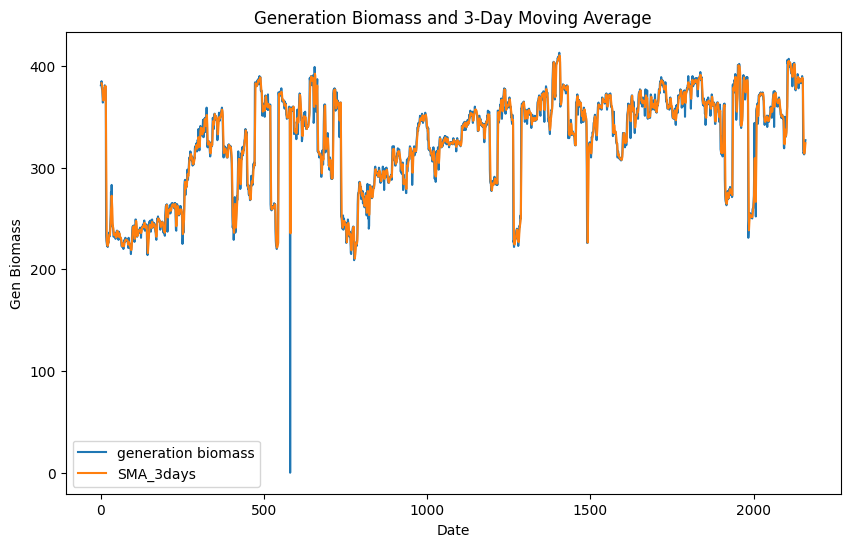

In [13]:
# Plot both 'Close' and 'SMA_3days' columns
import matplotlib.pyplot as plt
df[['generation biomass', 'SMA_3days']].plot(title='Generation Biomass and 3-Day Moving Average', figsize=(10, 6))
plt.xlabel('Date')
plt.ylabel('Gen Biomass')
plt.legend()
plt.show()

<Axes: ylabel='Density'>

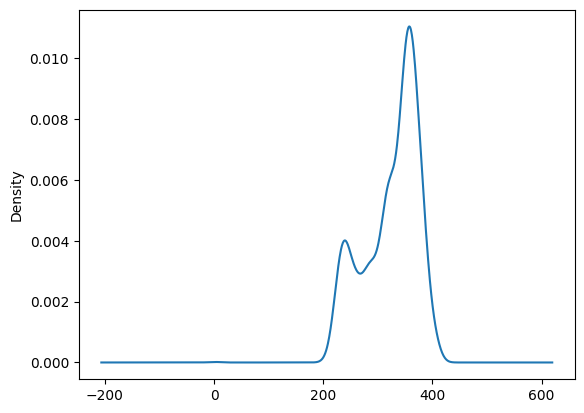

In [14]:
df["generation biomass"].plot.kde()

<Axes: title={'center': 'Histogram of t-2'}, ylabel='Frequency'>

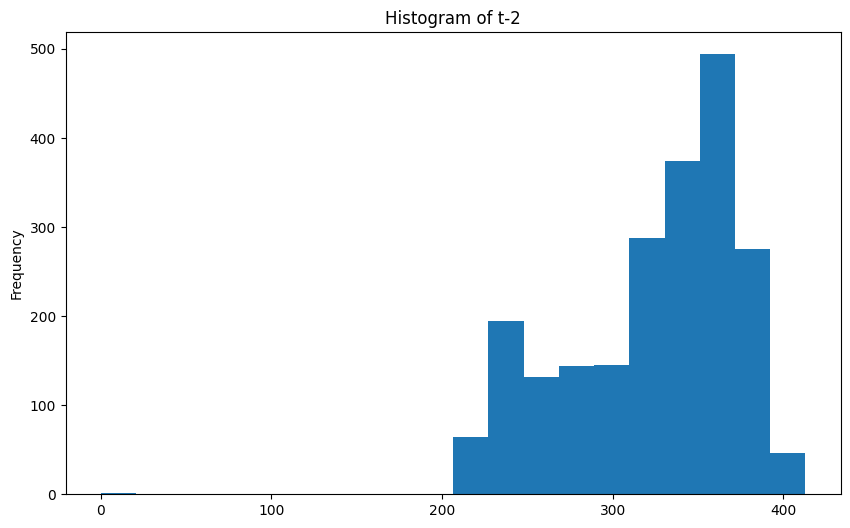

In [15]:
df["t-2"].plot.hist(bins=20, title='Histogram of t-2', figsize=(10, 6))

In [16]:
from KDEpy import FFTKDE

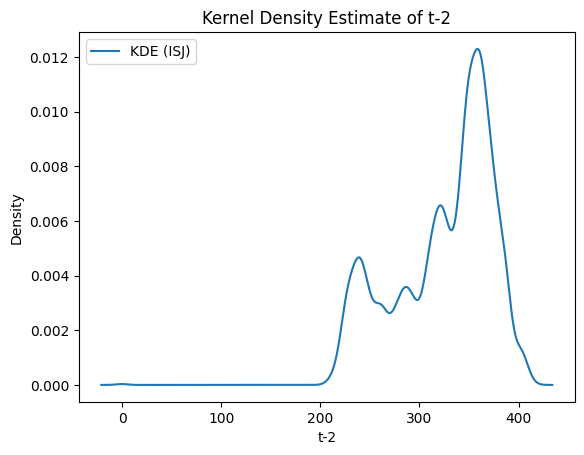

In [20]:
kde = FFTKDE(kernel='gaussian', bw='ISJ').fit(df["t-2"].dropna().values)
x, y = kde.evaluate()
plt.plot(x, y, label='KDE (ISJ)')
plt.title('Kernel Density Estimate of t-2')
plt.xlabel('t-2')
plt.ylabel('Density')
plt.legend()
plt.show()